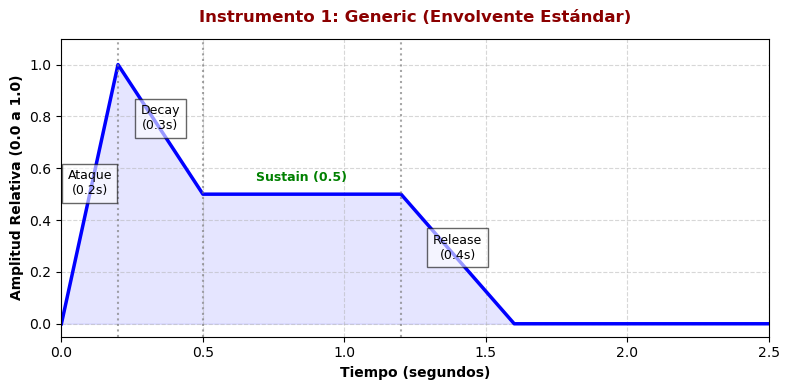

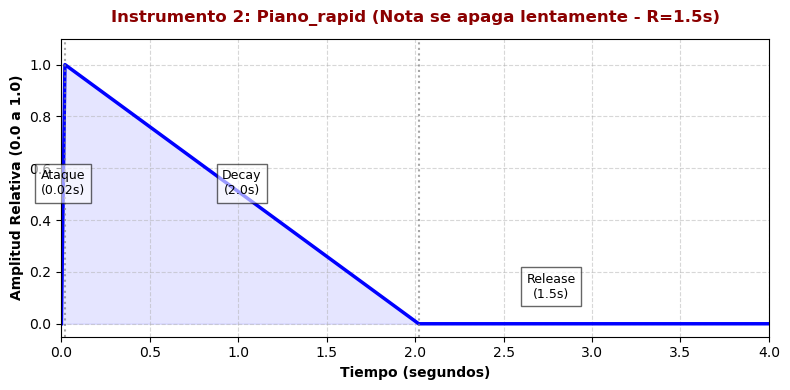

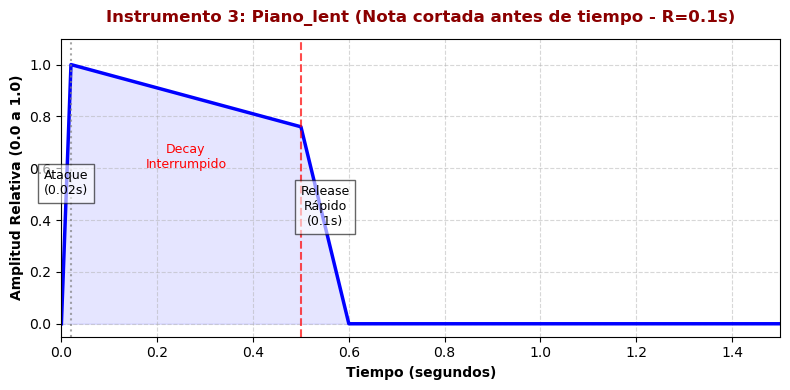

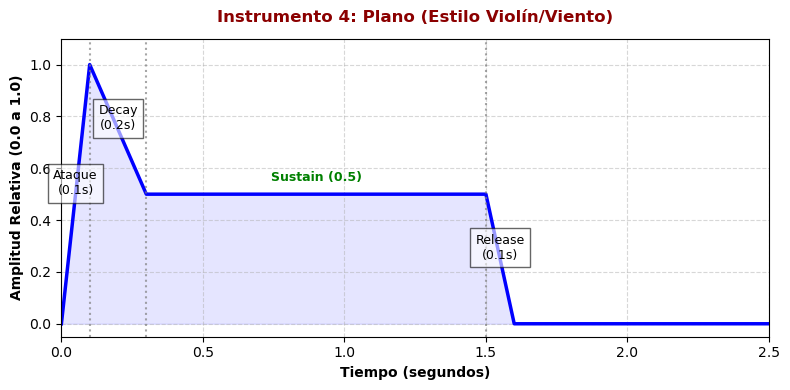

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_adsr(title, A, D, S, R, note_duration, total_time=3.0, cut_early=False):
    plt.figure(figsize=(8, 4))
    
    # Puntos temporales clave
    t_attack = A
    t_decay = A + D
    
    if cut_early:
        # El intérprete suelta la nota antes de que se extinga en el decay
        t_release_start = note_duration
        # Cálculo de la amplitud en el momento exacto del corte (interpolación lineal)
        amp_at_release = 1.0 - ((note_duration - t_attack) / D) * (1.0 - S)
        amp_at_release = max(amp_at_release, S)
    else:
        # Nota larga: se espera a que termine el decay (o pase el sustain)
        t_release_start = max(note_duration, t_decay) if S > 0 else t_decay
        amp_at_release = S if t_release_start >= t_decay else 1.0
        
    t_end = t_release_start + R
    
    # Construcción de los vectores de la curva
    times = [0, t_attack]
    amplitudes = [0, 1.0]
    
    if cut_early:
        times.append(t_release_start)
        amplitudes.append(amp_at_release)
    else:
        times.extend([t_decay, t_release_start])
        amplitudes.extend([S, S])
        
    times.append(t_end)
    amplitudes.append(0)
    
    # Rellenar con cero si el tiempo total de la gráfica es mayor
    if t_end < total_time:
        times.append(total_time)
        amplitudes.append(0)

    # Dibujar la envolvente ADSR
    plt.plot(times, amplitudes, 'b-', linewidth=2.5, label='Curva de Amplitud')
    plt.fill_between(times, amplitudes, color='blue', alpha=0.1)
    
    # Títulos y etiquetas (Valoración positiva de la memoria)
    plt.title(title, fontsize=12, fontweight='bold', pad=12, color='darkred')
    plt.xlabel('Tiempo (segundos)', fontsize=10, fontweight='bold')
    plt.ylabel('Amplitud Relativa (0.0 a 1.0)', fontsize=10, fontweight='bold')
    plt.xlim(0, total_time)
    plt.ylim(-0.05, 1.1)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Colocar etiquetas de texto explicativas dentro del gráfico
    plt.axvline(x=t_attack, color='gray', linestyle=':', alpha=0.7)
    plt.text(t_attack / 2, 0.5, f'Ataque\n({A}s)', horizontalalignment='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
    
    if cut_early:
        plt.axvline(x=t_release_start, color='red', linestyle='--', alpha=0.7)
        plt.text((t_attack + t_release_start) / 2, 0.6, 'Decay\nInterrumpido', horizontalalignment='center', color='red', fontsize=9)
        plt.text((t_release_start + t_end) / 2, amp_at_release / 2, f'Release\nRápido\n({R}s)', horizontalalignment='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
    else:
        plt.axvline(x=t_decay, color='gray', linestyle=':', alpha=0.7)
        plt.text((t_attack + t_decay) / 2, (1 + S) / 2 if S > 0 else 0.5, f'Decay\n({D}s)', horizontalalignment='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
        
        if S > 0:
            plt.axvline(x=t_release_start, color='gray', linestyle=':', alpha=0.7)
            plt.text((t_decay + t_release_start) / 2, S + 0.05, f'Sustain ({S})', horizontalalignment='center', fontweight='bold', fontsize=9, color='green')
            plt.text((t_release_start + t_end) / 2, S / 2, f'Release\n({R}s)', horizontalalignment='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))
        else:
            # Para el piano largo donde S=0, el release teórico está al final del decay
            plt.text((t_decay + t_end) / 2, 0.1, f'Release\n({R}s)', horizontalalignment='center', fontsize=9, bbox=dict(facecolor='white', alpha=0.6))

    plt.tight_layout()
    plt.show()

# ==========================================
# GENERACIÓN DE LAS 4 GRÁFICAS DEFINITIVAS
# ==========================================

# 1. Genérico
plot_adsr("Instrumento 1: Generic (Envolvente Estándar)", 
          A=0.2, D=0.3, S=0.5, R=0.4, note_duration=1.2, total_time=2.5)

# 2. Piano Rápido (Extinción lenta y larga por Release de 1.5s)
plot_adsr("Instrumento 2: Piano_rapid (Nota se apaga lentamente - R=1.5s)", 
          A=0.02, D=2.0, S=0.0, R=1.5, note_duration=2.0, total_time=4.0)

# 3. Piano Lento (Nota interrumpida a los 0.5 segundos, caída abrupta R=0.1s)
plot_adsr("Instrumento 3: Piano_lent (Nota cortada antes de tiempo - R=0.1s)", 
          A=0.02, D=2.0, S=0.0, R=0.1, note_duration=0.5, total_time=1.5, cut_early=True)

# 4. Plano (Cuerdas frotadas / Viento - Ataque y liberación rápidos)
plot_adsr("Instrumento 4: Plano (Estilo Violín/Viento)", 
          A=0.1, D=0.2, S=0.5, R=0.1, note_duration=1.5, total_time=2.5)